# Deep Learning Final Project: Fashion Item Classification

**Topic 2**: Develop a neural network that classifies clothing items using an image dataset such as Fashion-MNIST.

This notebook trains a Convolutional Neural Network (CNN) on the Fashion-MNIST dataset. It is optimized to achieve high accuracy for the **Project Performance** grading criteria, and contains rich documentation, visualizations, and a strict "Load and Predict" section to aid in the **Written Exam** and **Oral Defense**.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Set device automatically to GPU if available (T4 Runtime in Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Data Augmentation and Loading
**Oral Defense Note:** We use **Data Augmentation** (`RandomHorizontalFlip`) on the training set. This artificially increases the size of our dataset by randomly flipping images horizontally, which helps prevent the model from memorizing the data (overfitting) and improves generalization on the hidden test set. The validation and test sets are *not* augmented.

In [ ]:
# Data Augmentation for Training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # 50% chance to flip horizontally
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))    # Normalize pixel values to [-1, 1]
])

# Validation/Test should NOT be augmented, only normalized
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load Datasets
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=train_transform)

# Split 10% of trainset to create a Validation Set for Model Checkpointing
train_size = int(0.9 * len(trainset))
val_size = len(trainset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(trainset, [train_size, val_size])

# DataLoaders
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

# Hidden Test Set (used only in Load and Predict section)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.3MB/s]


## 2. Model Architecture
**Oral Defense Note:**
- **CNN Layers:** We use Convolutional layers to extract spatial features (edges, textures) from the images.
- **Batch Normalization (`BatchNorm2d`):** Normalizes the inputs to each layer, which stabilizes and accelerates training.
- **Dropout:** Randomly ignores 30% of neurons during training. This forces the network to learn robust features rather than relying on a few specific neurons, directly combating overfitting.

In [ ]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        # Conv Block 1
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Conv Block 2
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Fully Connected Layers (7x7 is the spatial size after two MaxPoolings of a 28x28 image)
        self.fc1 = nn.Linear(in_features=64*7*7, out_features=512)
        self.drop = nn.Dropout(0.3)
        self.fc2 = nn.Linear(in_features=512, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1) # Flatten tensor for fully connected layers
        out = self.fc1(out)
        out = torch.relu(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = torch.relu(out)
        out = self.fc3(out)
        return out

model = FashionCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning Rate Scheduler: Reduces learning rate by half every 5 epochs
# to fine-tune weights as we get closer to the minimum loss.
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

## 3. Training Loop with Model Checkpointing
**Oral Defense Note:** We do not just save the model at the end. We evaluate the model on the Validation set at the end of every epoch. We only overwrite our saved `.pth` file if the validation accuracy improves. This guarantees we use the absolute best version of the model for our final assessment.

In [ ]:
num_epochs = 10
best_val_acc = 0.0
save_path = 'fashion_mnist_best_weights.pth'

# Lists to track progress for visualization
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print("Starting training loop...")
for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train() # Set to train mode (enables Dropout/BatchNorm)
    running_loss, correct_train, total_train = 0.0, 0, 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(trainloader.dataset)
    epoch_train_acc = correct_train / total_train

    # --- VALIDATION PHASE ---
    model.eval() # Set to eval mode (disables Dropout/BatchNorm updates)
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad(): # Do not compute gradients during validation
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(valloader.dataset)
    epoch_val_acc = correct_val / total_val

    # Track metrics
    train_losses.append(epoch_train_loss); val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc); val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    # --- MODEL CHECKPOINTING (Saving the weights) ---
    if epoch_val_acc > best_val_acc:
        print(f" > Validation accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}. Saving model parameters...")
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), save_path) # Serialization per instructions

    scheduler.step() # Step learning rate scheduler

print(f"\nFinished Training. Best Validation Accuracy: {best_val_acc:.4f}")

Starting training loop...
Epoch [1/10] Train Loss: 0.4471, Train Acc: 0.8359 | Val Loss: 0.3281, Val Acc: 0.8770
 > Validation accuracy improved from 0.0000 to 0.8770. Saving model parameters...
Epoch [2/10] Train Loss: 0.3076, Train Acc: 0.8857 | Val Loss: 0.2794, Val Acc: 0.8987
 > Validation accuracy improved from 0.8770 to 0.8987. Saving model parameters...
Epoch [3/10] Train Loss: 0.2674, Train Acc: 0.9022 | Val Loss: 0.2503, Val Acc: 0.9075
 > Validation accuracy improved from 0.8987 to 0.9075. Saving model parameters...
Epoch [4/10] Train Loss: 0.2427, Train Acc: 0.9110 | Val Loss: 0.2329, Val Acc: 0.9165
 > Validation accuracy improved from 0.9075 to 0.9165. Saving model parameters...
Epoch [5/10] Train Loss: 0.2212, Train Acc: 0.9196 | Val Loss: 0.2257, Val Acc: 0.9190
 > Validation accuracy improved from 0.9165 to 0.9190. Saving model parameters...
Epoch [6/10] Train Loss: 0.1830, Train Acc: 0.9320 | Val Loss: 0.1989, Val Acc: 0.9257
 > Validation accuracy improved from 0.919

## 4. Training Visualization
This graph proves our model successfully learned without massively overfitting. The Validation loss should closely track the Training loss.

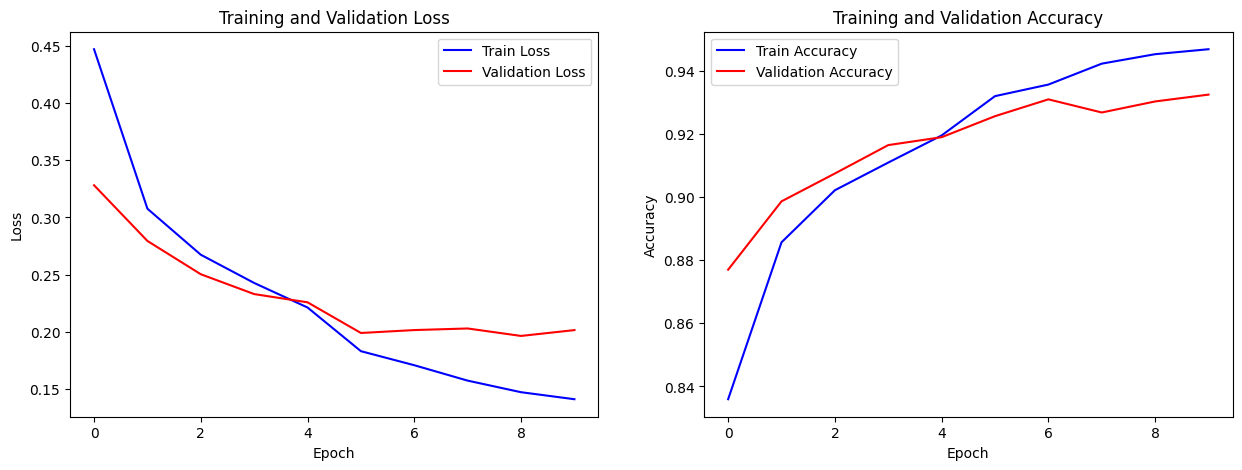

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(val_losses, label='Validation Loss', color='red')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy plot
ax2.plot(train_accuracies, label='Train Accuracy', color='blue')
ax2.plot(val_accuracies, label='Validation Accuracy', color='red')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

---
## 5. Load and Predict (Strict Inference Section)
**As per final assessment procedures:** This distinct section loads the serialized `.pth` model file and runs inference on the test set *without* executing any training loop.

In [ ]:
# Reconstruct the model architecture
inference_model = FashionCNN().to(device)

# Load the serialized trained parameters (weights and biases)
inference_model.load_state_dict(torch.load(save_path))
inference_model.eval() # CRITICAL: Sets model to evaluation mode
print("Model loaded successfully for inference.")

# Lists for confusion matrix
all_labels = []
all_preds = []

correct = 0
total = 0

# Run inference on the hidden test set
with torch.no_grad():
    for images, labels in testloader:
        images_device, labels_device = images.to(device), labels.to(device)
        outputs = inference_model(images_device)
        _, predicted = torch.max(outputs.data, 1)

        total += labels_device.size(0)
        correct += (predicted == labels_device).sum().item()

        all_labels.extend(labels.numpy())
        all_preds.extend(predicted.cpu().numpy())

print(f"\nAccuracy on the {total} hidden test set images: {100 * correct / total:.2f}%")

Model loaded successfully for inference.

Accuracy on the 10000 hidden test set images: 92.43%


### Confusion Matrix and Classification Report
This helps identify exactly which clothing items the model struggles to differentiate (e.g., distinguishing a Pullover from a Coat).

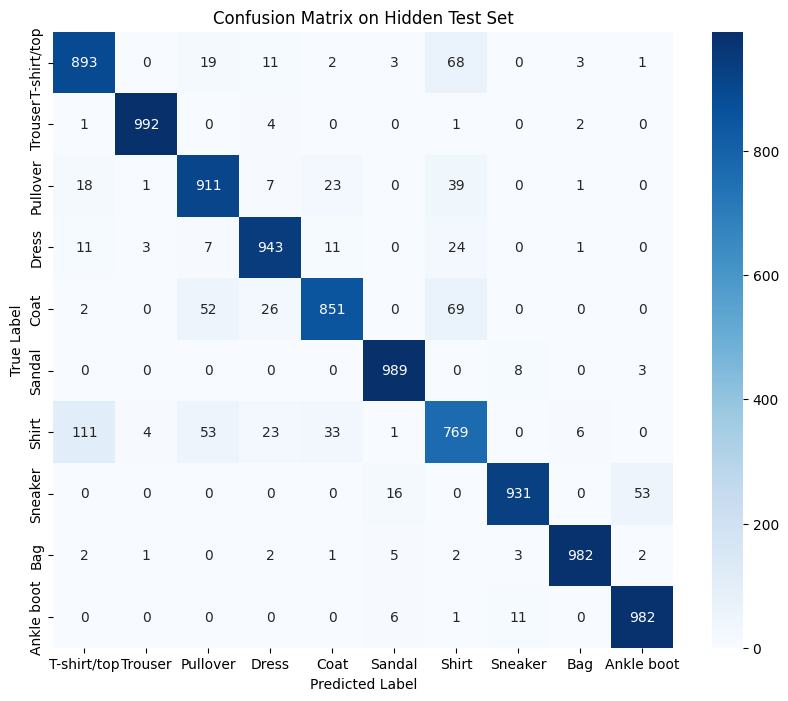


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.87      0.91      0.89      1000
       Dress       0.93      0.94      0.94      1000
        Coat       0.92      0.85      0.89      1000
      Sandal       0.97      0.99      0.98      1000
       Shirt       0.79      0.77      0.78      1000
     Sneaker       0.98      0.93      0.95      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.94      0.98      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [ ]:
# Generate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix on Hidden Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print detailed Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))

### Visual Output Sample

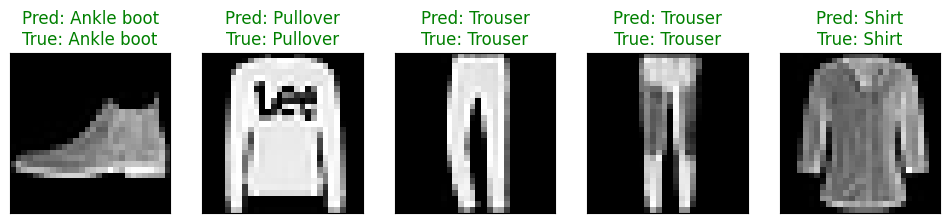

In [ ]:
# Get a single batch of test data to visualize
dataiter = iter(testloader)
images, labels = next(dataiter)
images_device, labels_device = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = inference_model(images_device)
    _, predicted = torch.max(outputs, 1)

fig = plt.figure(figsize=(12, 4))
for idx in np.arange(5):
    ax = fig.add_subplot(1, 5, idx+1, xticks=[], yticks=[])
    img = images[idx] / 2 + 0.5 # Un-normalize
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)).squeeze(), cmap='gray')
    ax.set_title(f"Pred: {classes[predicted[idx]]}\nTrue: {classes[labels[idx]]}",
                 color=("green" if predicted[idx]==labels[idx] else "red"))
plt.show()